# Phase 1: Project Planning

In [33]:
Step 1 — Problem Statement & Business Understanding

Business Understanding (why does this project exist in the real world?)

Banks and lending institutions (credit card companies, NBFCs, microfinance institutions) face a core risk: when someone applies for credit, 
the bank doesn't know in advance if that person will repay on time or default. Give too much credit to risky people → bank loses money (defaults, write-offs).
Be too conservative → bank rejects good customers and loses business to competitors.
Problem Statement (the ML framing)

Given a customer's financial and demographic attributes (income, age, loan amount, credit history, employment, existing debts, etc.), 
predict whether the customer is likely to be a "Good Credit" (will repay) or "Bad Credit" (likely to default) risk.

This is a binary classification problem, and — important detail I want you to internalize now because it affects almost every later phase — in credit risk problems, the cost of misclassification is asymmetric:

Predicting "Good" when actually "Bad" (False Negative) → bank loses money on a bad loan. Usually very costly.
Predicting "Bad" when actually "Good" (False Positive) → bank loses a potential good customer. Costly, but usually less severe than the above.

This asymmetry is why, later in Phase 7, we won't just look at accuracy — we'll care a lot about Recall for the "Bad Credit" class and 
things like ROC-AUC. I'm flagging it now so it's in your head from day one, like a real risk analyst would think about it.

## Lib Import

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\Work\Credit Default Risk ML\Data\raw\german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Dataset Shape

In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn info:")
df.info()

Shape of dataset: (1000, 11)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


### Check Missing Values

In [5]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df

,Missing Count,Missing %
Checking account,394,39.4
Saving accounts,183,18.3


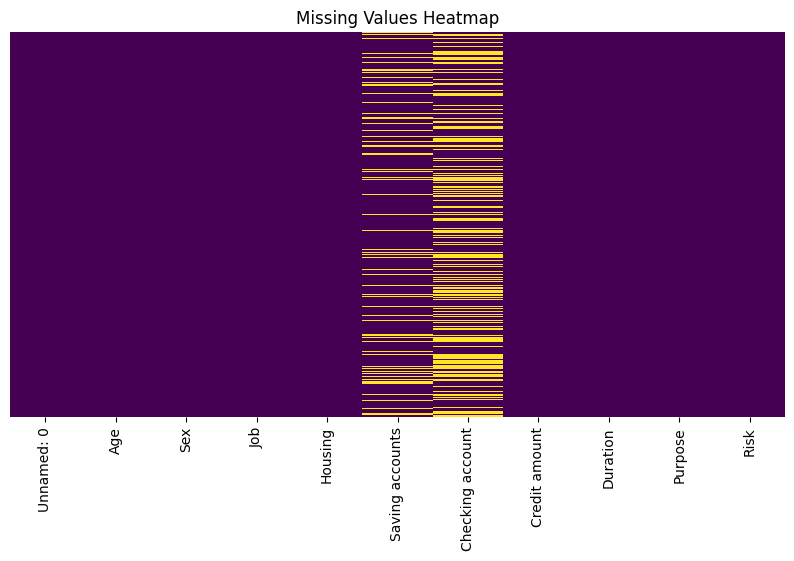

In [9]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### Duplicate Value Check

In [10]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Target Value Analysis

In [11]:
# Count and percentage
print(df['Risk'].value_counts())
print()
print(df['Risk'].value_counts(normalize=True) * 100)

Risk
good    700
bad     300
Name: count, dtype: int64

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


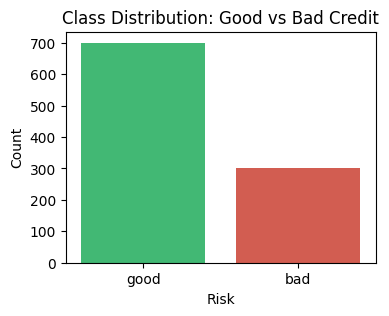

In [24]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='Risk', palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution: Good vs Bad Credit')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.show()

## Univariate Analysis - Numerical Features (Age, Credit amount, Duration)

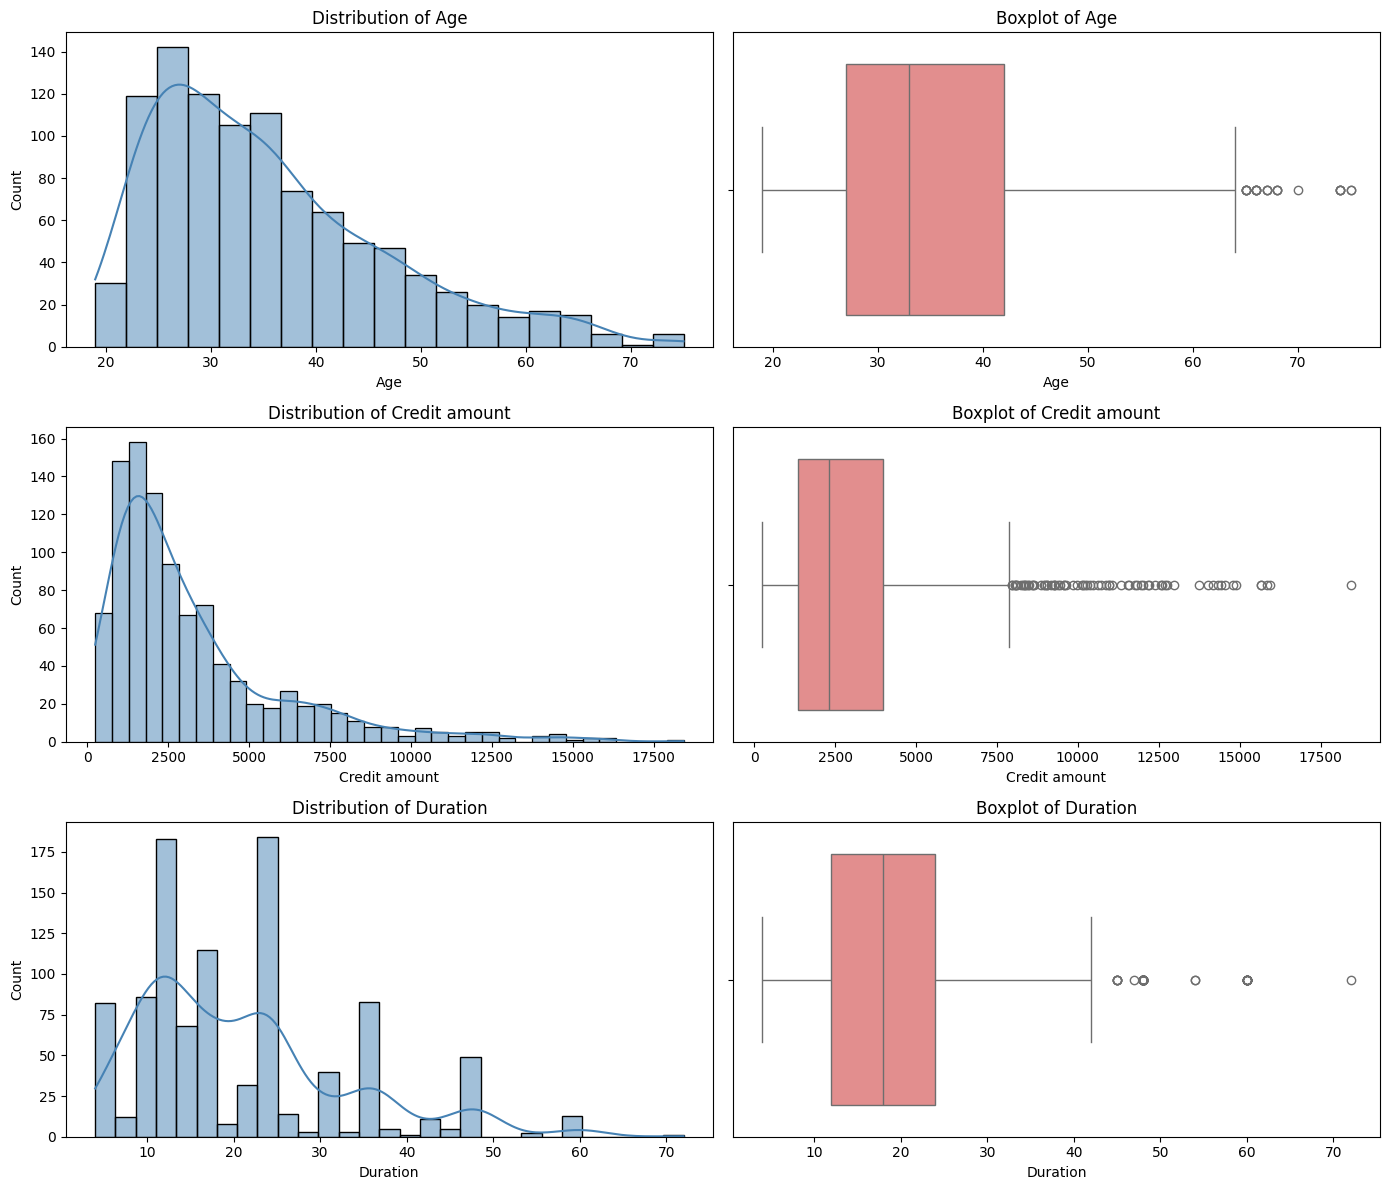

In [17]:
numerical_cols = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(numerical_cols):
    # Histogram with KDE (smoothed distribution curve)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [19]:
# Quick interpretation guide for skewness values:
# Close to 0 → symmetric
# > 1 → highly right-skewed (long tail toward large values)
# < -1 → highly left-skewed
    
for col in numerical_cols:
    print(f"{col}: skewness = {df[col].skew():.2f}")

Age: skewness = 1.02
Credit amount: skewness = 1.95
Duration: skewness = 1.09


## Univariate Analysis — Categorical Features
   -- Sex, Housing, Purpose, Job, Saving accounts, Checking account

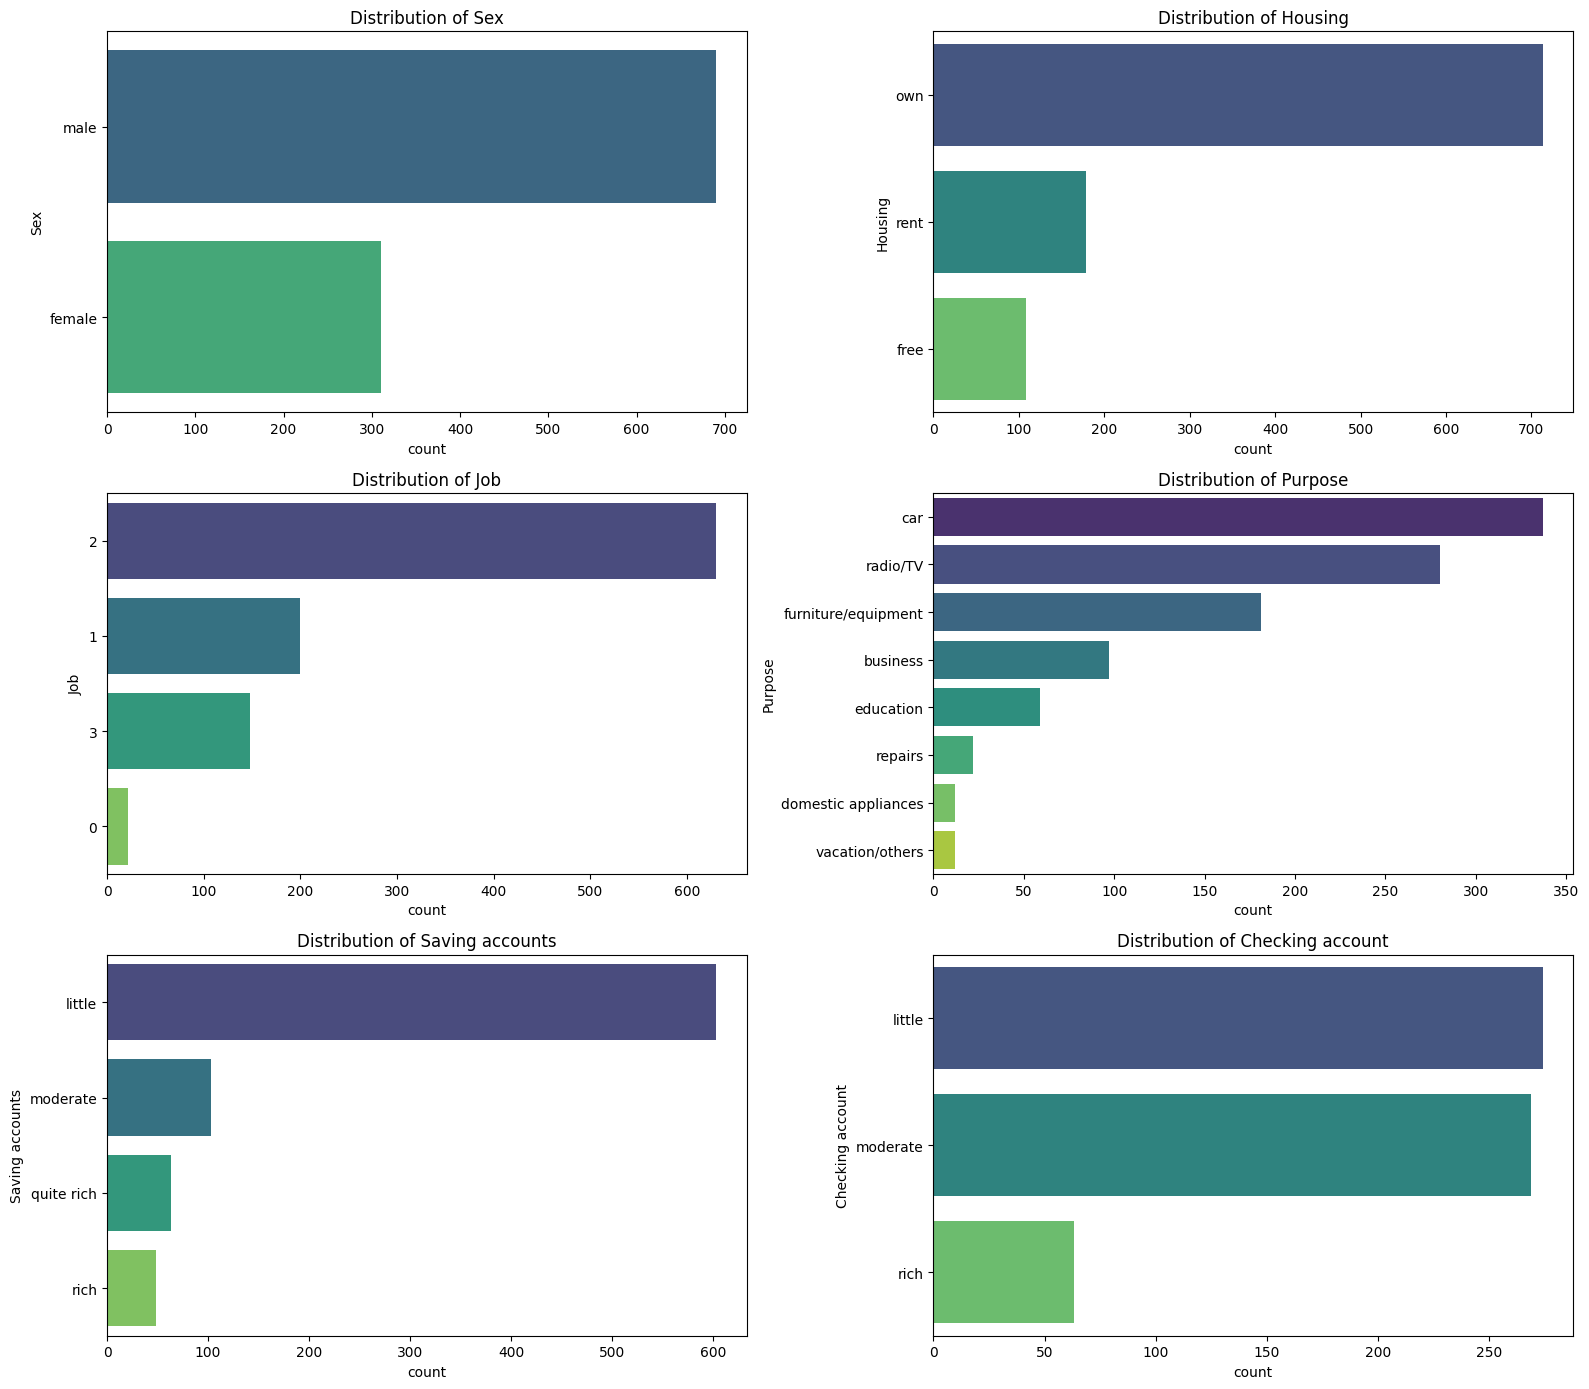

In [23]:
import warnings
warnings.filterwarnings("ignore")
categorical_cols = ['Sex', 'Housing', 'Job', 'Purpose', 'Saving accounts', 'Checking account']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [25]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Sex ---
Sex
male      690
female    310
Name: count, dtype: int64

--- Housing ---
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

--- Job ---
Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

--- Purpose ---
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

--- Saving accounts ---
Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

--- Checking account ---
Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64


## Bivariate Analysis — Features vs Target (RISK)

### Part A: Numerical Features vs Risk (Age, Credit amount, Duration)

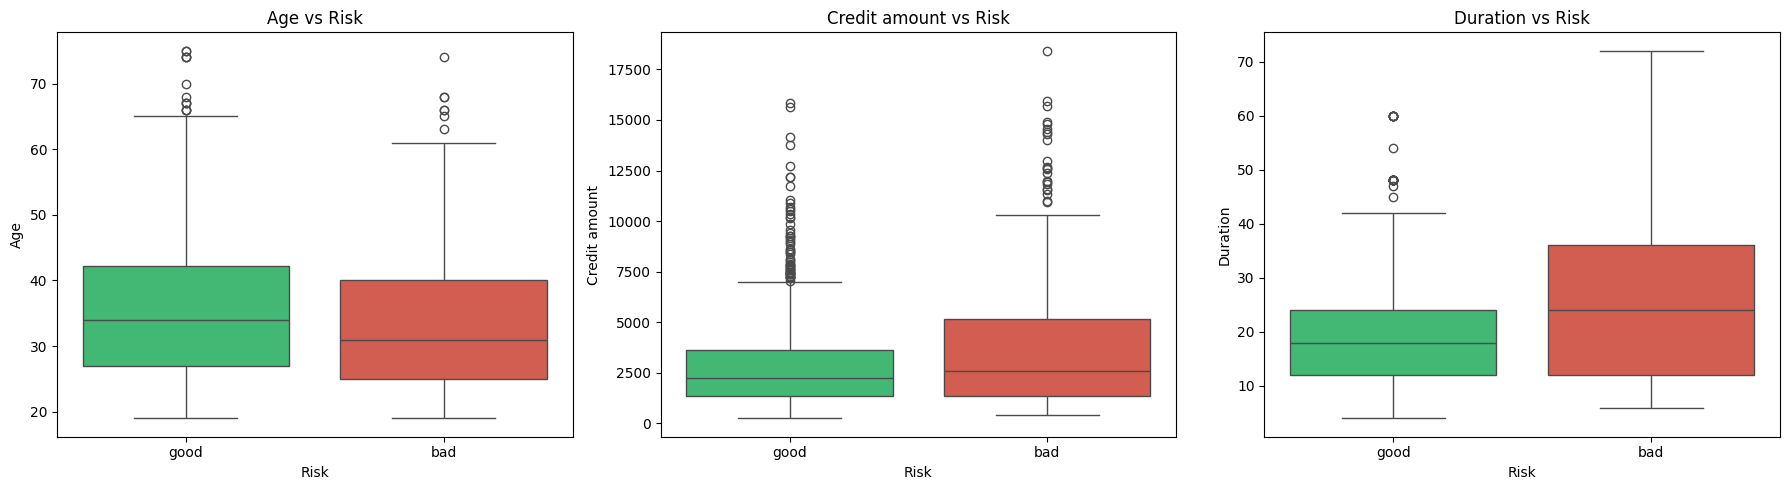

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Risk', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Risk')

plt.tight_layout()
plt.show()

## Part B: Categorical Features vs Risk

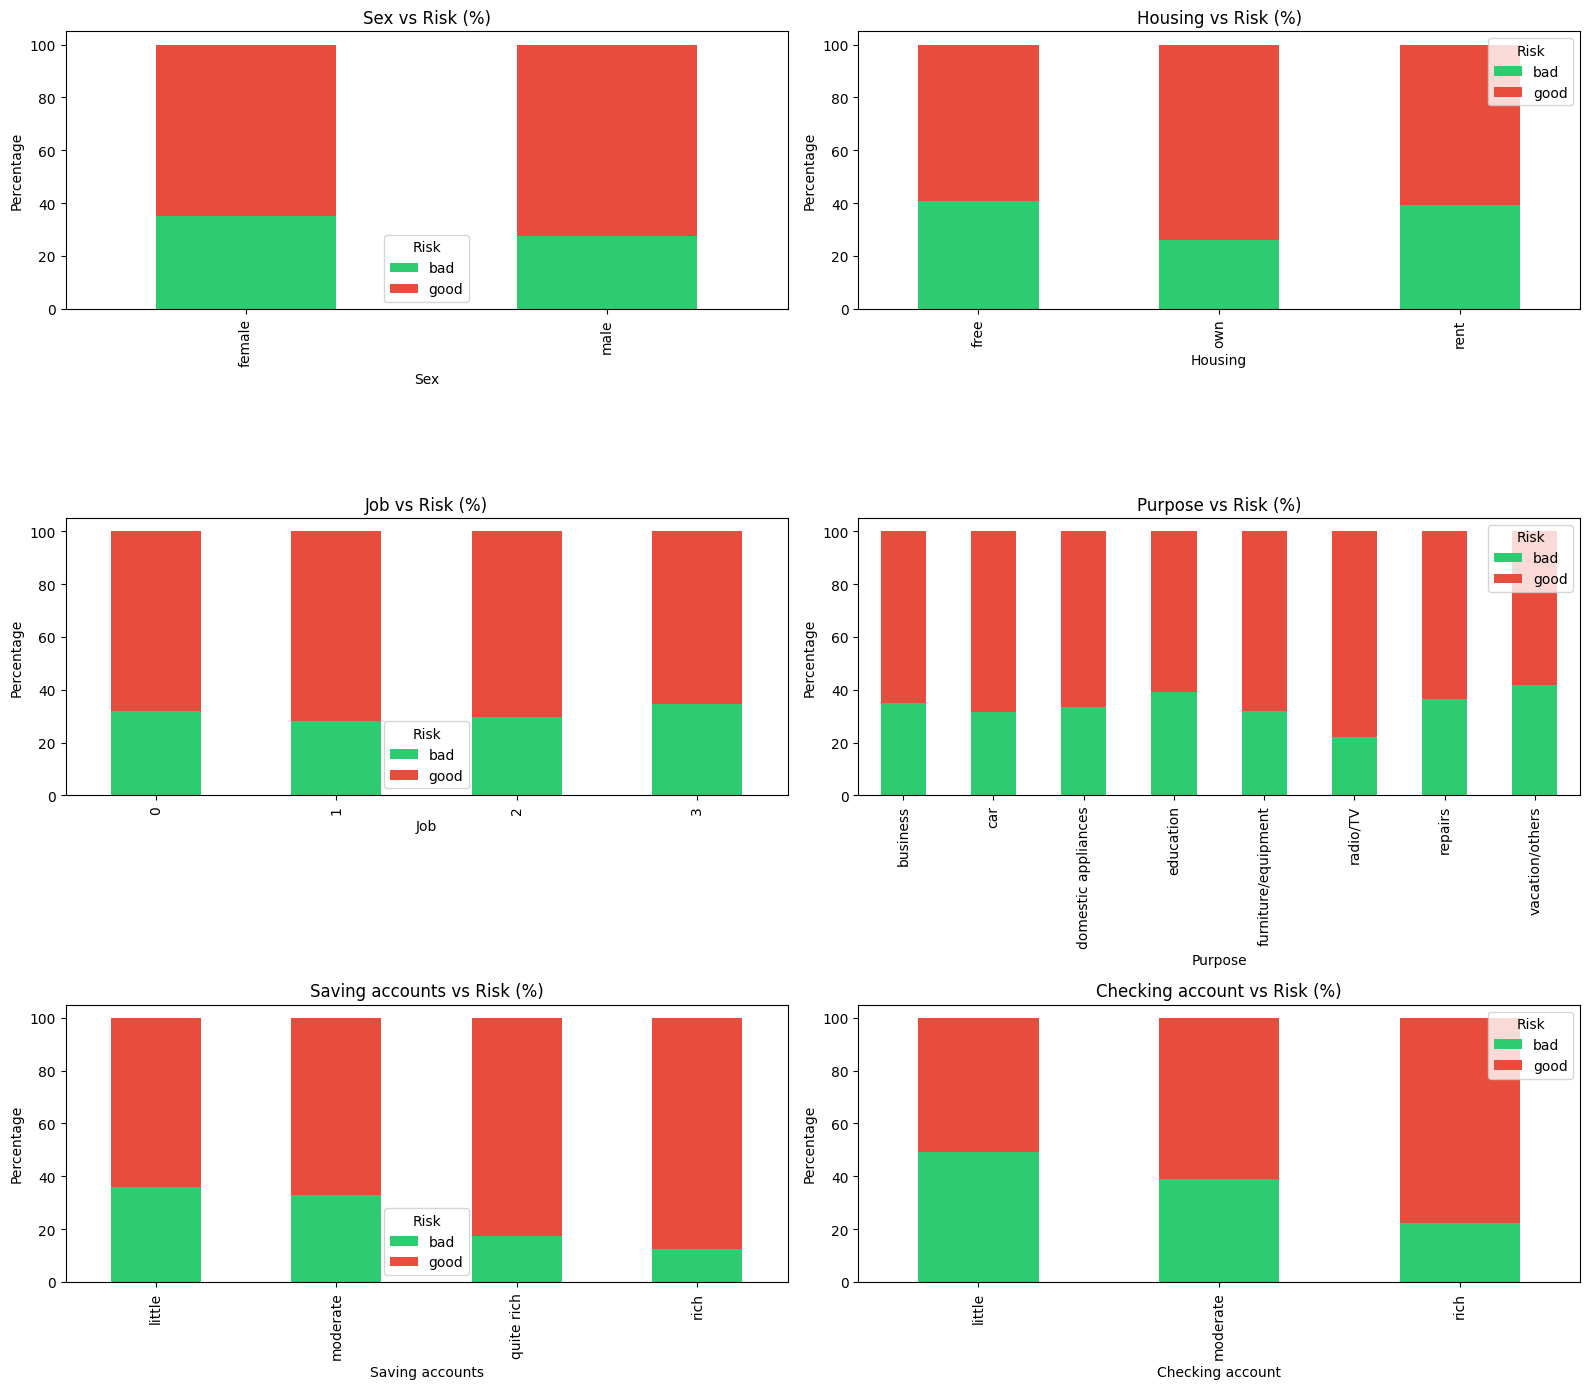

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Risk'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Risk (%)')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(title='Risk')

plt.tight_layout()
plt.show()

## Correlation Analysis (Numerical Features)

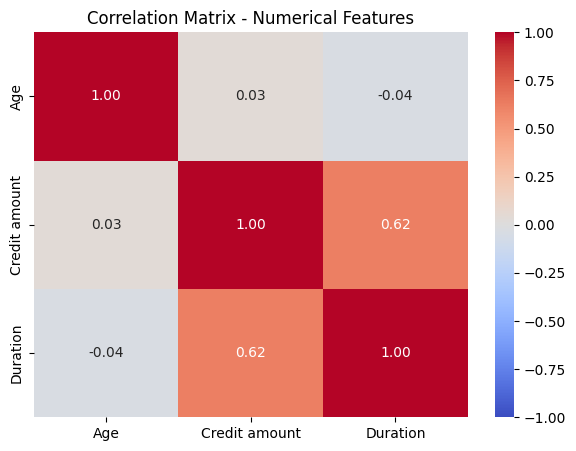

In [28]:
plt.figure(figsize=(7, 5))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Numerical Features')
plt.show()

### Outlier Detection (Formal, using IQR method)

In [29]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in numerical_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    pct = (count / len(df)) * 100
    print(f"{col}: {count} outliers ({pct:.2f}%) | Valid range: [{lower:.2f}, {upper:.2f}]")

Age: 23 outliers (2.30%) | Valid range: [4.50, 64.50]
Credit amount: 72 outliers (7.20%) | Valid range: [-2544.62, 7882.38]
Duration: 70 outliers (7.00%) | Valid range: [-6.00, 42.00]


# Phase 2 Wrap-Up: EDA Summary
Let's consolidate everything into a clean summary — this is exactly what you'd put as a markdown cell at the end of your EDA notebook, and it's also the raw material for your README's "Key Insights" section later.
Dataset Understanding

1000 customers, 10 features, target Risk (good/bad), no duplicate rows
Missing data concentrated in Checking account (39.4%) and Saving accounts (18.3%) — hypothesized to mean "no such account" rather than data entry errors

Class Distribution

70% good credit / 30% bad credit — moderate imbalance, requires careful metric choice (not accuracy alone) in later phases

Numerical Features

All three (Age, Credit amount, Duration) are right-skewed
Credit amount most skewed (1.95) — expected for financial amount data
Outliers present (2–7%) but represent legitimate high-value customers, not data errors — likely retained, especially given tree-based models are planned

Bivariate Insights

Duration and Credit amount trend higher for "bad" credit customers — longer/larger loans carry more risk
Checking account status shows a strong relationship with Risk — likely a top predictive feature
Housing and Saving accounts also show meaningful separation
Sex flagged for fairness/bias awareness — a real-world consideration for credit models

Correlation

Credit amount & Duration: 0.62 (moderate, expected, not problematic)

#### Legitimate Outliers
Example:
Loan Amount = ₹1.5 Crore
Is that wrong?
No.
Maybe the customer is a businessman.
Maybe the customer owns a company.
Maybe they are purchasing commercial property.
    
This is real business data.
Removing it would make the model less representative of the real world.

# Phase 3: Data Cleaning

In [34]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')
# Verify no missing values remain
print(df.isnull().sum())

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [43]:
df[['Saving accounts']].value_counts()
df[['Checking account']].value_counts()

Checking account
none                394
little              274
moderate            269
rich                 63
Name: count, dtype: int64

In [35]:
pd.crosstab(df['Checking account'], df['Risk'], normalize='index') * 100

Risk,bad,good
Checking account,,
little,49.270073,50.729927
moderate,39.033457,60.966543
none,11.675127,88.324873
rich,22.222222,77.777778


In [38]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


### Save Clean Data:

In [46]:
df.to_csv('../data/processed/cleaned_data.csv', index=False)
print("Cleaned dataset saved successfully.")
print("Final shape:", df.shape)

Cleaned dataset saved successfully.
Final shape: (1000, 10)
